In [ ]:
pip install torch torchvision pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.5/80.5 MB 33.4 MB/s  0:00:02m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 16.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [torchvision] [torchvision]
Note: you may need to restart the kernel to use updated packages.


Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Total images found: 10015
Train size: 7991 | Test size: 2024
Train malignant: 1561 | Train benign: 6430

Batch size: 32
Train batches: 250 | Test batches: 64


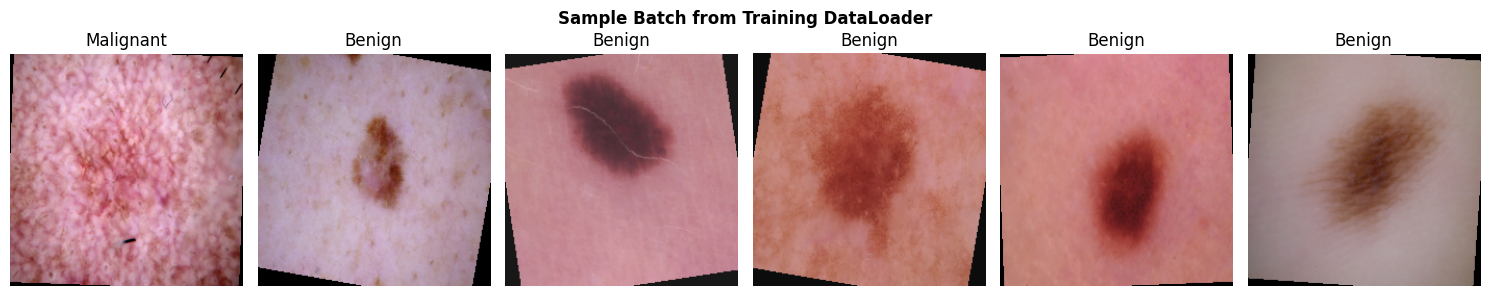


Preprocessing complete. Ready for model training.


In [1]:
import os
import pandas as pd
import numpy as np
from PIL import Image
from collections import Counter

import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms

import kagglehub
import matplotlib.pyplot as plt

# ── 1. Load dataset ────────────────────────────────────────────────────────────
path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
csv_path = os.path.join(path, "HAM10000_metadata.csv")
df = pd.read_csv(csv_path)

# HAM10000 images are split across two folders
img_dirs = [
    os.path.join(path, "HAM10000_images_part_1"),
    os.path.join(path, "HAM10000_images_part_2"),
]

# Build a dict mapping image_id -> full file path
img_paths = {}
for d in img_dirs:
    if os.path.exists(d):
        for fname in os.listdir(d):
            if fname.endswith(".jpg"):
                img_id = fname.replace(".jpg", "")
                img_paths[img_id] = os.path.join(d, fname)

print(f"Total images found: {len(img_paths)}")

# ── 2. Binary label + train/test split (group by lesion_id) ───────────────────
malignant = ["mel", "bcc", "akiec"]
df["label"] = df["dx"].isin(malignant).astype(int)

# Only keep rows where we actually have the image file
df = df[df["image_id"].isin(img_paths)].reset_index(drop=True)
df["filepath"] = df["image_id"].map(img_paths)

# Group-aware train/test split (same logic as LR — no lesion leakage)
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df, df["label"], df["lesion_id"]))

train_df = df.iloc[train_idx].reset_index(drop=True)
test_df  = df.iloc[test_idx].reset_index(drop=True)

print(f"Train size: {len(train_df)} | Test size: {len(test_df)}")
print(f"Train malignant: {train_df['label'].sum()} | Train benign: {(train_df['label']==0).sum()}")

# ── 3. Transforms ──────────────────────────────────────────────────────────────
# ResNet-18 expects 224x224 images normalized with ImageNet mean/std
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Training: augment minority (malignant) class to reduce imbalance
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Test: no augmentation, just resize and normalize
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# ── 4. Custom Dataset ──────────────────────────────────────────────────────────
class SkinLesionDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df        = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = Image.open(row["filepath"]).convert("RGB")
        label = torch.tensor(row["label"], dtype=torch.long)
        if self.transform:
            img = self.transform(img)
        return img, label

train_dataset = SkinLesionDataset(train_df, transform=train_transform)
test_dataset  = SkinLesionDataset(test_df,  transform=test_transform)

# ── 5. Weighted sampler (oversamples malignant during training) ────────────────
# This ensures each batch sees a roughly equal mix of benign/malignant
label_counts  = Counter(train_df["label"])
class_weights = {cls: 1.0 / count for cls, count in label_counts.items()}
sample_weights = [class_weights[l] for l in train_df["label"]]
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# ── 6. DataLoaders ─────────────────────────────────────────────────────────────
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"\nBatch size: {BATCH_SIZE}")
print(f"Train batches: {len(train_loader)} | Test batches: {len(test_loader)}")

# ── 7. Sanity check — preview a batch ─────────────────────────────────────────
def imshow_batch(loader, n=6):
    imgs, labels = next(iter(loader))
    # Unnormalize for display
    mean = torch.tensor(IMAGENET_MEAN).view(3,1,1)
    std  = torch.tensor(IMAGENET_STD).view(3,1,1)
    imgs = imgs * std + mean
    imgs = imgs.clamp(0, 1)

    fig, axes = plt.subplots(1, n, figsize=(15, 3))
    for i in range(n):
        axes[i].imshow(imgs[i].permute(1, 2, 0).numpy())
        axes[i].set_title("Malignant" if labels[i].item() == 1 else "Benign")
        axes[i].axis("off")
    plt.suptitle("Sample Batch from Training DataLoader", fontweight="bold")
    plt.tight_layout()
    plt.show()

imshow_batch(train_loader)
print("\nPreprocessing complete. Ready for model training.")

Using device: cuda
ResNet-18 loaded. layer4 + final layer unfrozen for fine-tuning.

Epoch 01/10 | Train Loss: 0.4038  Train Acc: 0.8075 | Test Loss: 0.6606  Test Acc: 0.6655
Epoch 02/10 | Train Loss: 0.3496  Train Acc: 0.8407 | Test Loss: 0.3464  Test Acc: 0.8325
Epoch 03/10 | Train Loss: 0.3125  Train Acc: 0.8662 | Test Loss: 0.4471  Test Acc: 0.8068
Epoch 04/10 | Train Loss: 0.2768  Train Acc: 0.8842 | Test Loss: 0.4504  Test Acc: 0.7920
Epoch 05/10 | Train Loss: 0.2610  Train Acc: 0.8919 | Test Loss: 0.3973  Test Acc: 0.8281
Epoch 06/10 | Train Loss: 0.2153  Train Acc: 0.9129 | Test Loss: 0.4641  Test Acc: 0.8103
Epoch 07/10 | Train Loss: 0.2067  Train Acc: 0.9162 | Test Loss: 0.4881  Test Acc: 0.8004
Epoch 08/10 | Train Loss: 0.1775  Train Acc: 0.9279 | Test Loss: 0.4352  Test Acc: 0.8162
Epoch 09/10 | Train Loss: 0.1538  Train Acc: 0.9426 | Test Loss: 0.4593  Test Acc: 0.8320
Epoch 10/10 | Train Loss: 0.1425  Train Acc: 0.9451 | Test Loss: 0.4445  Test Acc: 0.8424


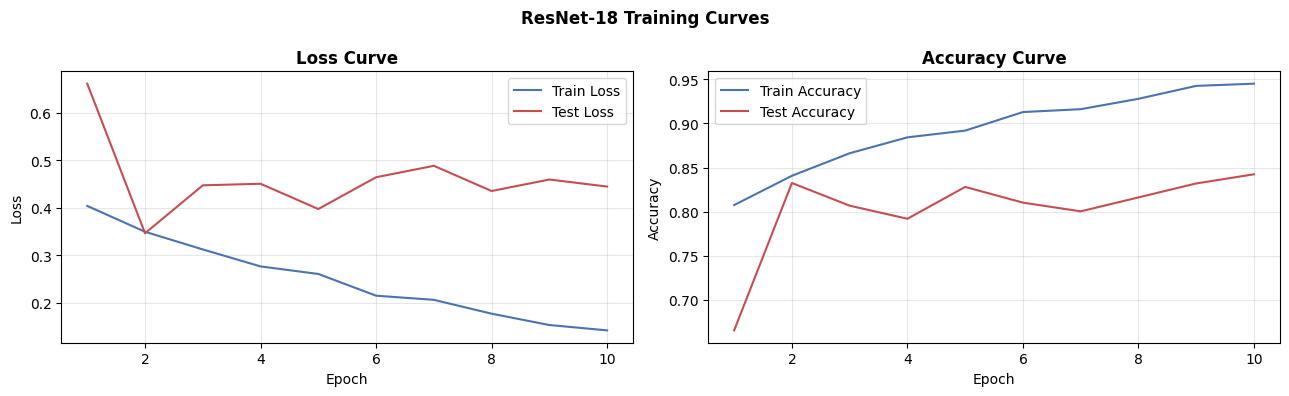


Model saved to resnet18_skin_lesion.pth


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

#  1. Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

#  2. Load pretrained ResNet-18 and modify final layer
model = models.resnet18(weights="IMAGENET1K_V1")

# Unfreeze only the last residual block (layer4) and final fc layer
# This gives the model enough capacity to learn skin lesion features
# without overfitting from training too many parameters
for param in model.parameters():
    param.requires_grad = False
for param in model.layer4.parameters():
    param.requires_grad = True

# Swap final fully connected layer: 512 -> 2 (benign / malignant)
model.fc = nn.Linear(model.fc.in_features, 2)

model = model.to(device)
print("ResNet-18 loaded. layer4 + final layer unfrozen for fine-tuning.\n")

#  3. Loss, optimizer, scheduler
# Lower lr (1e-4) to avoid overwriting pretrained weights too aggressively
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4
)

# Reduce LR by half if validation loss stops improving
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=2
)

#  4. Training loop
NUM_EPOCHS = 10

train_losses, test_losses = [], []
train_accs,   test_accs   = [], []

for epoch in range(NUM_EPOCHS):
    # -- Training --
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        preds         = outputs.argmax(dim=1)
        correct      += (preds == labels).sum().item()
        total        += labels.size(0)

    train_loss = running_loss / total
    train_acc  = correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # -- Evaluation --
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs  = model(imgs)
            loss     = criterion(outputs, labels)
            val_loss += loss.item() * imgs.size(0)
            preds     = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total   += labels.size(0)

    test_loss = val_loss / val_total
    test_acc  = val_correct / val_total
    test_losses.append(test_loss)
    test_accs.append(test_acc)

    scheduler.step(test_loss)

    print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.4f} | "
          f"Test Loss: {test_loss:.4f}  Test Acc: {test_acc:.4f}")

#  5. Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(range(1, NUM_EPOCHS+1), train_losses, label="Train Loss", color="#4C72B0")
axes[0].plot(range(1, NUM_EPOCHS+1), test_losses,  label="Test Loss",  color="#C44E52")
axes[0].set_title("Loss Curve", fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, NUM_EPOCHS+1), train_accs, label="Train Accuracy", color="#4C72B0")
axes[1].plot(range(1, NUM_EPOCHS+1), test_accs,  label="Test Accuracy",  color="#C44E52")
axes[1].set_title("Accuracy Curve", fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("ResNet-18 Training Curves", fontweight="bold")
plt.tight_layout()
plt.savefig("cnn_training_curves.png", dpi=150)
plt.show()

#  6. Save model
torch.save(model.state_dict(), "resnet18_skin_lesion.pth")
print("\nModel saved to resnet18_skin_lesion.pth")

=== ResNet-18 (Transfer Learning) — Test Set Metrics ===

Accuracy:  0.8424
Precision: 0.5777
Recall:    0.6997
F1 Score:  0.6329
ROC-AUC:   0.8988


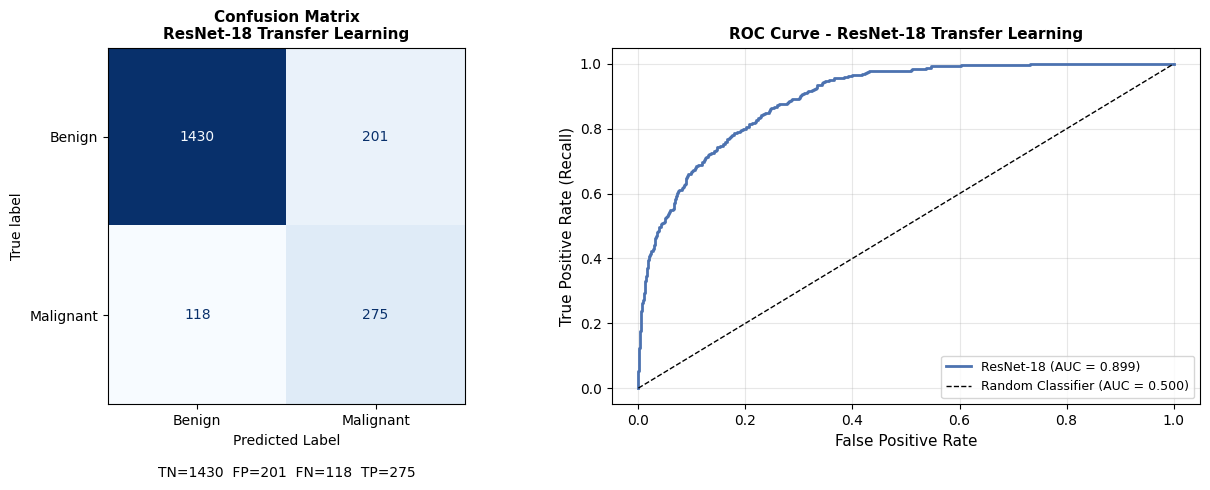

In [5]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import numpy as np
import torch

#  1. Collect all predictions and probabilities on the test set
model.eval()
all_labels, all_preds, all_probs = [], [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs   = imgs.to(device)
        outputs = model(imgs)
        probs   = torch.softmax(outputs, dim=1)[:, 1]  # prob of malignant
        preds   = outputs.argmax(dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_labels = np.array(all_labels)
all_preds  = np.array(all_preds)
all_probs  = np.array(all_probs)

#  2. Print metrics
print("=== ResNet-18 (Transfer Learning) — Test Set Metrics ===\n")
print(f"Accuracy:  {accuracy_score(all_labels, all_preds):.4f}")
print(f"Precision: {precision_score(all_labels, all_preds):.4f}")
print(f"Recall:    {recall_score(all_labels, all_preds):.4f}")
print(f"F1 Score:  {f1_score(all_labels, all_preds):.4f}")
print(f"ROC-AUC:   {roc_auc_score(all_labels, all_probs):.4f}")

#  3. Confusion matrix + ROC curve
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix
cm   = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=["Benign", "Malignant"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
tn, fp, fn, tp = cm.ravel()
axes[0].set_title("Confusion Matrix\nResNet-18 Transfer Learning",
                  fontsize=11, fontweight="bold")
axes[0].set_xlabel(f"Predicted Label\n\nTN={tn}  FP={fp}  FN={fn}  TP={tp}",
                   fontsize=10)

# ROC curve
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
auc = roc_auc_score(all_labels, all_probs)

axes[1].plot(fpr, tpr, color="#4C72B0", lw=2,
             label=f"ResNet-18 (AUC = {auc:.3f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=1,
             label="Random Classifier (AUC = 0.500)")
axes[1].set_xlabel("False Positive Rate", fontsize=11)
axes[1].set_ylabel("True Positive Rate (Recall)", fontsize=11)
axes[1].set_title("ROC Curve - ResNet-18 Transfer Learning",
                  fontsize=11, fontweight="bold")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("cnn_confusion_roc.png", dpi=150)
plt.show()